In [5]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input

In [6]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 50
IMAGES_PATH = "/Volumes/T9/HAM10000"
CSV_PATH = "/Volumes/T9/HAM10000_metadata.csv"
df = pd.read_csv("/Volumes/T9/HAM10000_metadata.csv")
# Définition des classes à conserver
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

In [4]:

# 📁 Mapping des chemins images dans une nouvelle colonne 'path'
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))

# 🏷️ Label to index mapping
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
df = df[df['dx'].isin(CLASS_LABELS.values())]
df['label'] = df['dx'].map(label_to_index)


In [7]:
import os
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd

# === 0. Paramètres ===
DATASET_DIR = '/Volumes/T9/HAM10000'  # répertoire contenant toutes les images originales
SAVE_DIR = '/Volumes/T9/HAM10000/data_split'  # répertoire cible pour sauvegarde
os.makedirs(SAVE_DIR, exist_ok=True)

# === 1. Split en 70% train, 15% val, 15% test ===
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Conversion des labels en str (requis pour Keras et ImageDataGenerator)
for subset in [train_df, val_df, test_df]:
    subset['label'] = subset['label'].astype(str)



KeyError: 'label'

In [5]:
# === 2. Sauvegarde des DataFrames en CSV pour traçabilité future ===
train_df.to_csv(os.path.join(SAVE_DIR, 'train_labels.csv'), index=False)
val_df.to_csv(os.path.join(SAVE_DIR, 'val_labels.csv'), index=False)
test_df.to_csv(os.path.join(SAVE_DIR, 'test_labels.csv'), index=False)

# === 3. Copie physique des images ===
def save_images_from_df(df, subset_name):
    subset_dir = os.path.join(SAVE_DIR, subset_name)
    os.makedirs(subset_dir, exist_ok=True)
    
    for _, row in df.iterrows():
        image_filename = row['image_id']  # ou 'image' si c'est la colonne dans ton CSV
        possible_extensions = ['.jpg', '.jpeg', '.png']
        
        # Trouver le fichier existant avec une des extensions
        for ext in possible_extensions:
            test_path = os.path.join(DATASET_DIR, image_filename + ext)
            if os.path.exists(test_path):
                src_path = test_path
                break
        else:
            print(f"[⚠️] Image introuvable : {image_filename}")
            continue

        class_dir = os.path.join(subset_dir, row['label'])
        os.makedirs(class_dir, exist_ok=True)
        dst_path = os.path.join(class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)


save_images_from_df(train_df, 'train')
save_images_from_df(val_df, 'val')
save_images_from_df(test_df, 'test')


In [5]:
def print_class_distribution(df, name="Dataset"):
    print(f"\n📊 Répartition dans {name} :")
    dist = df['label'].value_counts().sort_index()
    for i, count in dist.items():
        print(f"{CLASS_LABELS[int(i)]:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test")


📊 Répartition dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition dans Test :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112


In [11]:
# Facteurs de sampling (uniquement pour train)
sampling_factors = {
    0: 2,    # akiec
    1: 1,     # bcc
    2: 1,   # bkl
    3: 5,    # df
    4: 1,  # nv
    5: 3,    # vasc
    6: 3    # mel
}

# Vérification des répartitions
def print_class_distribution(df, name="Dataset"):
    dist = df['label'].value_counts().sort_index()
    print(f"\n📊 Répartition des classes dans {name} :")
    for i, count in dist.items():
        class_name = CLASS_LABELS[int(i)]
        print(f"{class_name:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test Interne")

def resample_dataframe(df, factors):
    resampled_df = []

    for label, factor in factors.items():
        subset = df[df['label'] == str(label)]
        n_samples = int(len(subset) * factor)

        if factor > 1:
            duplicated = pd.concat([subset] * int(factor), ignore_index=True)
            remainder = int((factor % 1) * len(subset))
            if remainder > 0:
                duplicated = pd.concat([duplicated, subset.sample(n=remainder, replace=True, random_state=42)], ignore_index=True)
        elif factor < 1:
            duplicated = subset.sample(n=n_samples, random_state=42)
        else:
            duplicated = subset

        resampled_df.append(duplicated)

    return pd.concat(resampled_df, ignore_index=True).sample(frac=1, random_state=42)

# ➕ Application du resampling uniquement sur le train
train_df_balanced = resample_dataframe(train_df, sampling_factors)

# 🔍 Vérification finale
print_class_distribution(train_df_balanced, "Train (Resampled)")



📊 Répartition des classes dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition des classes dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition des classes dans Test Interne :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112

📊 Répartition des classes dans Train (Resampled) :
akiec  : 524
bcc    : 411
bkl    : 879
df     : 460
nv     : 5364
vasc   : 342
mel    : 2670


In [24]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# --- 📸 Data Augmentation pour l'entraînement ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,                 
    rotation_range=35,
    zoom_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect',
    channel_shift_range=15.0,

)

# --- 🔍 Pas d'augmentation pour validation / test ---
val_test_datagen = ImageDataGenerator(
   preprocessing_function=preprocess_input              
)

# --- 🔁 Train generator ---
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    #sample_weight=sample_weights
)

# --- 🎯 Validation generator ---
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# --- 🧪 Test generator ---
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 8012 validated image filenames belonging to 7 classes.
Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


In [6]:
images, labels = next(train_generator)
print(f"Nouvelle plage des pixels : {images.min()} {images.max()}")

Nouvelle plage des pixels : -1.0 1.0


In [7]:
# 🔁 Conversion des labels en string
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)
#train_df_balanced['label'] = train_df_balanced['label'].astype(str)

In [36]:
# Alpha Pondéré

import numpy as np
from collections import Counter
from tqdm import tqdm

class_counts = Counter()

# Assure-toi que train_generator is not infinite (no shuffle, no repeat)
for i in tqdm(range(len(train_generator))):
    _, y_batch = train_generator[i]
    labels = np.argmax(y_batch, axis=1)
    class_counts.update(labels)

# Affichage propre
print("\n==> Distribution par classe :")
for idx, count in class_counts.items():
    print(f"Classe {idx} ({CLASS_LABELS[idx]}): {count} images")

# Calcul alpha pondéré inversé
total = sum(class_counts.values())
alpha = [total / class_counts[i] for i in range(len(CLASS_LABELS))]
alpha = np.array(alpha)
alpha = alpha / np.sum(alpha)

print("\n==> Alpha pondéré (normalisé) :")
for idx, a in enumerate(alpha):
    print(f"{CLASS_LABELS[idx]} (classe {idx}) : {a:.4f}")


100%|██████████| 251/251 [01:22<00:00,  3.04it/s]


==> Distribution par classe :
Classe 4 (nv): 5364 images
Classe 2 (bkl): 879 images
Classe 6 (mel): 890 images
Classe 5 (vasc): 114 images
Classe 1 (bcc): 411 images
Classe 0 (akiec): 262 images
Classe 3 (df): 92 images

==> Alpha pondéré (normalisé) :
akiec (classe 0) : 0.1347
bcc (classe 1) : 0.0859
bkl (classe 2) : 0.0401
df (classe 3) : 0.3836
nv (classe 4) : 0.0066
vasc (classe 5) : 0.3095
mel (classe 6) : 0.0396


In [10]:
alpha = np.array([0.1347, 0.0859, 0.0401, 0.3836, 0.0066, 0.3095, 0.0396])

In [11]:
#Bosst Alpha en phase de Tuning si besoin
import numpy as np

# Alpha initial
#alpha = np.array([0.08044085, 0.12819649, 0.04796428, 0.3818026,
#                  0.01964532, 0.3081214, 0.03382906])

# Coefficients de boost personnalisés
boost_factors = {
    0: 1.5,  # akiec
    1: 1.,  # bcc
    2: 1.,  # bkl
    3: 2,  # df
    4: 1,  # nv
    5: 1,  # vasc
    6: 2   # mel
}

# Appliquer les boosts
alpha_boosted = alpha.copy()
for idx, factor in boost_factors.items():
    alpha_boosted[idx] *= factor

# (Optionnel) Re-normaliser
alpha_boosted /= alpha_boosted.sum()

print(alpha_boosted)


[0.13555399 0.05762973 0.02690282 0.51470934 0.0044279  0.20764147
 0.05313475]


In [35]:
import tensorflow as tf
from tensorflow.keras import backend as K

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.metrics import Recall, Precision, AUC
from tensorflow.keras import mixed_precision


# ⚙️ Politique de précision mixte
mixed_precision.set_global_policy('mixed_float16')



In [33]:
# === 3. Focal Loss (float32) ===
def focal_loss(alpha = alpha_boosted, gamma=2.5):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)

        # Sélectionner alpha correspondant à la vraie classe
        alpha_factor = tf.reduce_sum(alpha * y_true, axis=-1, keepdims=True)

        # Probabilité prédite pour la vraie classe
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)

        # Focal factor
        focal_factor = tf.pow(1. - p_t, gamma)

        # Cross entropy
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1, keepdims=True)

        # Focal loss combiné
        loss = alpha_factor * focal_factor * ce
        return tf.reduce_mean(loss)
    return loss


In [8]:

import tensorflow as tf

def focal_loss(alpha=None, gamma=3.5):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)

        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_factor = tf.reduce_sum(y_true * alpha_tensor, axis=-1)
        else:
            alpha_factor = tf.ones(tf.shape(y_true)[0], dtype=tf.float32)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_factor = tf.pow(1. - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        return tf.reduce_mean(alpha_factor * focal_factor * ce)

    return loss


In [47]:
alpha_boosted = np.array([0.23318888, 0.04955027, 0.04633712, 0.44272091, 0.00379664,
       0.17864177, 0.04576441])

In [92]:
alpha_boosted

array([0.21194374, 0.06755822, 0.06317731, 0.36218584, 0.01037584,
       0.09744063, 0.18731842])

In [20]:
import tensorflow as tf

from tensorflow.keras.models import Model
# Importations manquantes ajoutées
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import mixed_precision, layers 
from tensorflow.keras.activations import swish

# === 1. Politique Mixed Precision ===
mixed_precision.set_global_policy('mixed_float16')

# === 1. Paramètres ===

N_CLASSES = 7

# === 3. Construction du modèle ===

base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = True


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='swish')(x)  # ✅ Swish ici
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

output = layers.Dense(
    N_CLASSES,
    activation='softmax',
    dtype='float32',

)(x)

model = Model(inputs=base_model.input, outputs=output, name='HAM10000_Xception')

# === 4. Compilation ===
optimizer = AdamW(learning_rate=1e-3)



In [10]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def get_class_weights(train_df, train_generator, use_emphasis=True):
    train_df['label'] = train_df['label'].astype(str)

    class_names = list(train_generator.class_indices.keys())
    label_to_index = train_generator.class_indices
    y_indices = train_df['label'].map(label_to_index).values

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.arange(len(class_names)),
        y=y_indices
    )

    if use_emphasis:
        emphasis = {'mel': 1.5, 'akiec': 2.0, 'df': 1.5}
        for label, factor in emphasis.items():
            if label in label_to_index:
                idx = label_to_index[label]
                class_weights[idx] *= factor

    # ✅ C’est cette ligne qui corrige ton bug
    return {i: float(weight) for i, weight in enumerate(class_weights)}



In [43]:
class_weight = get_class_weights(train_df, train_generator, use_emphasis=True)


In [21]:
model.compile(
    optimizer=optimizer,
    #loss= 'categorical_crossentropy',  # Focal loss personnalisée
    loss = focal_loss(alpha=None, gamma=2.),
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)

In [54]:



from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CHECKPOINT_AUC = 'Protocole-S-V2-Xception-phaseAvecTAG3-valAUC.keras'
CHECKPOINT_ACC = 'Protocole-S-V2-Xception-phaseSAvecTAG3-valACC.keras'

callbacks = [
    # Early stopping sur val_auc (objectif principal)
    EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1,
        mode='max',

    ),

    # Sauvegarde du meilleur modèle basé sur val_auc
    ModelCheckpoint(
        filepath=CHECKPOINT_AUC,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Sauvegarde secondaire sur val_accuracy
    ModelCheckpoint(
        filepath=CHECKPOINT_ACC,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Réduction du learning rate sur stagnation du val_auc
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.9,
        patience=4,
        min_lr=1e-6,
        min_delta=1e-4,
        mode='max',
        verbose=1
    ),
]


In [23]:

# 3. Continuer l'entraînement
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    initial_epoch=0,
    callbacks=callbacks,
    #class_weight=class_weight,
    verbose=1
)

Epoch 1/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5149 - auc: 0.8200 - loss: 1.1476 - precision: 0.6501 - recall: 0.3333
Epoch 1: val_auc improved from -inf to 0.94969, saving model to Protocole-S-V2-Xception-phase1-valAUC.keras

Epoch 1: val_accuracy improved from -inf to 0.72428, saving model to Protocole-S-V2-Xception-phase1-valACC.keras
333/333 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.5151 - auc: 0.8202 - loss: 1.1466 - precision: 0.6504 - recall: 0.3335 - val_accuracy: 0.7243 - val_auc: 0.9497 - val_loss: 0.4671 - val_precision: 0.8824 - val_recall: 0.5994 - learning_rate: 0.0010
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6990 - auc: 0.9450 - loss: 0.4458 - precision: 0.7963 - recall: 0.5592
Epoch 2: val_auc improved from 0.94969 to 0.95136, saving model to Protocole-S-V2-Xception-phase1-valAUC.keras

Epoch 2: val_accuracy did not improve from 0.72428
333/333 ━━━━━━━━━━━━━━━━━━━━ 433s 1s/step - accuracy: 0.6990 - auc: 0.9450 - loss: 0.44

KeyboardInterrupt: 

In [74]:
# Vérification du nombre de couches dégelées
num_trainable = sum([layer.trainable for layer in model.layers])
print(f"Nombre total de couches dégelées : {num_trainable}")

Nombre total de couches dégelées : 3


In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Assure-toi que les labels sont bien en string partout
train_df['label'] = train_df['label'].astype(str)

# Liste des classes connues par le generator
class_names = np.array(list(train_generator.class_indices.keys()))  # Ex: ['0', '1', '2', ...]

# Calcul des poids équilibrés
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_names,
    y=train_df['label']
)

# Met l'accent sur certaines classes
# Exemple : classe '0' x6 et classe '6' x2
emphasis = {'0': 1.5, '3' : 2, '6': 1.5}
for i, label in enumerate(class_names):
    if label in emphasis:
        class_weights[i] *= emphasis[label]

# Mapping avec les bons indices du générateur
class_weight_dict = {
    train_generator.class_indices[label]: weight
    for label, weight in zip(class_names, class_weights)
}


NameError: name 'train_generator' is not defined

In [10]:
class_weight_dict

{0: np.float64(6.552889858233369),
 1: np.float64(2.7848453249913105),
 2: np.float64(1.3021290427433772),
 3: np.float64(24.88198757763975),
 4: np.float64(0.21338020666879728),
 5: np.float64(10.040100250626567),
 6: np.float64(1.9290529695024077)}

In [32]:
print(train_generator.class_indices)


{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6}


In [25]:
def targeted_focal_loss(target_classes, gamma=3.5, alpha=0.25, label_smoothing=0.0):
    # alpha peut être float ou dict {class_idx: alpha_value}
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        
        focal = tf.pow(1 - y_pred, gamma) * ce
        
        mask = tf.zeros_like(y_true)
        for c in target_classes:
            mask = tf.tensor_scatter_nd_update(mask, [[0, c]], [1.0])
        
        if isinstance(alpha, dict):
            alpha_vec = tf.zeros_like(y_true)
            for c in target_classes:
                alpha_val = alpha.get(c, 0.25)
                alpha_vec = tf.tensor_scatter_nd_update(alpha_vec, [[0, c]], [alpha_val])
        else:
            alpha_vec = alpha * mask
        
        focal_masked = alpha_vec * focal * mask
        ce_masked = ce * (1 - mask)
        
        loss_per_sample = tf.reduce_sum(focal_masked + ce_masked, axis=1)
        return tf.reduce_mean(loss_per_sample)
    return loss


In [26]:
#A utiliser
import tensorflow as tf
import numpy as np
import pandas as pd
import os

class TargetedAugmentGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, img_size, batch_size, class_names, augment=True, cache=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.batch_size = batch_size
        self.augment = augment
        self.class_names = class_names
        self.strong_aug_classes = ['mel', 'bcc', 'akiec', 'df']  # ← correctif de syntaxe ici
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        try:
            batch_df = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size]
            batch_images = []
            batch_labels = []

            for _, row in batch_df.iterrows():
                try:
                    img = self.load_image(row['path'])
                except Exception as e:
                    print(f"[ERROR] Failed to load image: {row['path']} - {e}")
                    continue

                label = self.encode_label(row['label'])

                if self.augment:
                    if row['label'] in self.strong_aug_classes:
                        img = self.strong_augmentation(img)
                    else:
                        img = self.standard_augmentation(img)

                img = tf.keras.applications.inception_v3.preprocess_input(img)
                batch_images.append(img)
                batch_labels.append(label)

            if not batch_images:
                raise ValueError("No valid images in batch.")

            return tf.stack(batch_images), tf.stack(batch_labels)
        
        except Exception as e:
            print(f"[CRITICAL] Batch generation failed at index {index}: {e}")
            raise

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        return img

    def encode_label(self, label):
        one_hot = tf.one_hot(self.class_names.index(label), depth=len(self.class_names))
        return one_hot

    def strong_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 1, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, 0.7, 1.3)
        img = tf.image.random_saturation(img, 0.7, 1.3)

        if tf.random.uniform(()) > 0.5:
            crop_frac = tf.random.uniform((), 0.8, 1.0)
            new_size = tf.cast(crop_frac * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.random_crop(img, size=[new_size[0], new_size[1], 3])
            img = tf.image.resize(img, self.img_size)

        if tf.random.uniform(()) > 0.5:
            mask_size = int(tf.random.uniform((), 0.1, 0.3) * self.img_size[0])
            img = self.apply_cutout(img, mask_size)

        img = tf.clip_by_value(img, 0.0, 255.0)
        return img

    def apply_cutout(self, img, size):
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]

        cy = tf.random.uniform((), 0, h, dtype=tf.int32)
        cx = tf.random.uniform((), 0, w, dtype=tf.int32)

        y1 = tf.clip_by_value(cy - size // 2, 0, h)
        y2 = tf.clip_by_value(cy + size // 2, 0, h)
        x1 = tf.clip_by_value(cx - size // 2, 0, w)
        x2 = tf.clip_by_value(cx + size // 2, 0, w)

        mask = tf.ones_like(img)
        mask = tf.tensor_scatter_nd_update(
            mask,
            indices=tf.stack(
                tf.meshgrid(tf.range(y1, y2), tf.range(x1, x2), indexing='ij'),
                axis=-1
            ).reshape([-1, 2]),
            updates=tf.zeros([((y2 - y1) * (x2 - x1)), 3])
        )

        return img * mask

    def standard_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        img = tf.clip_by_value(img, 0.0, 255.0)
        return img


In [27]:
# Toutes les classes dans l'ordre
class_names = sorted(train_df['label'].unique().tolist())

train_gen = TargetedAugmentGenerator(train_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=True)
val_gen = TargetedAugmentGenerator(val_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=False)
test_gen = TargetedAugmentGenerator(test_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=False)


In [28]:
# --- ✅ Remplacement par Custom Generator ---
class_names = sorted(train_df['label'].unique().tolist())

train_gen = TargetedAugmentGenerator(
    dataframe=train_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=class_names,
    augment=True
)

val_gen = TargetedAugmentGenerator(
    dataframe=val_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=class_names,
    augment=False
)

test_gen = TargetedAugmentGenerator(
    dataframe=test_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=class_names,
    augment=False
)


In [38]:
import tensorflow as tf
import numpy as np

class TargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = class_names
        self.batch_size = batch_size
        self.augment = augment
        self.strong_aug_classes = ['mel', 'bcc', 'akiec', 'df']

    def get_dataset(self):
        dataset = tf.data.Dataset.from_generator(
            self.generator,
            output_signature=(
                tf.TensorSpec(shape=(self.img_size[0], self.img_size[1], 3), dtype=tf.float32),
                tf.TensorSpec(shape=(len(self.class_names),), dtype=tf.float32)
            )
        )
        return dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)

    def generator(self):
        for _, row in self.df.iterrows():
            try:
                img = self.load_image(row['path'])

                if self.augment:
                    if row['label'] in self.strong_aug_classes:
                        img = self.strong_augmentation(img)
                    else:
                        img = self.standard_augmentation(img)

                img = tf.keras.applications.inception_v3.preprocess_input(img)
                label = self.encode_label(row['label'])

                yield img, label
            except Exception as e:
                print(f"[ERROR] Skipping {row['path']} due to: {e}")
                continue

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        return img

    def encode_label(self, label):
        one_hot = tf.one_hot(self.class_names.index(label), depth=len(self.class_names))
        return one_hot

    def strong_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 1, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, 0.7, 1.3)
        img = tf.image.random_saturation(img, 0.7, 1.3)

        if tf.random.uniform(()) > 0.5:
            crop_frac = tf.random.uniform((), 0.8, 1.0)
            new_size = tf.cast(crop_frac * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.random_crop(img, size=[new_size[0], new_size[1], 3])
            img = tf.image.resize(img, self.img_size)

        if tf.random.uniform(()) > 0.5:
            mask_size = int(tf.random.uniform((), 0.1, 0.3) * self.img_size[0])
            img = self.apply_cutout(img, mask_size)

        return tf.clip_by_value(img, 0.0, 255.0)

    def standard_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        return tf.clip_by_value(img, 0.0, 255.0)

    def apply_cutout(self, img, size):
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]
        cy = tf.random.uniform((), 0, h, dtype=tf.int32)
        cx = tf.random.uniform((), 0, w, dtype=tf.int32)
        y1 = tf.clip_by_value(cy - size // 2, 0, h)
        y2 = tf.clip_by_value(cy + size // 2, 0, h)
        x1 = tf.clip_by_value(cx - size // 2, 0, w)
        x2 = tf.clip_by_value(cx + size // 2, 0, w)

        # Create mask with ones and cutout region to zeros
        mask = tf.ones_like(img)
        ys, xs = tf.meshgrid(tf.range(y1, y2), tf.range(x1, x2), indexing='ij')
        indices = tf.stack([ys, xs], axis=-1)
        indices = tf.reshape(indices, [-1, 2])
        updates = tf.zeros([tf.shape(indices)[0], 3])

        mask = tf.tensor_scatter_nd_update(mask, indices, updates)
        return img * mask


In [ ]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np

class TargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = class_names
        self.batch_size = batch_size
        self.augment = augment
        self.strong_aug_classes = ['mel', 'bcc', 'akiec', 'df']

    def get_dataset(self):
        dataset = tf.data.Dataset.from_generator(
            self.generator,
            output_signature=(
                tf.TensorSpec(shape=(self.img_size[0], self.img_size[1], 3), dtype=tf.float32),
                tf.TensorSpec(shape=(len(self.class_names),), dtype=tf.float32)
            )
        )
        return dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)

    def generator(self):
        for _, row in self.df.iterrows():
            try:
                img = self.load_image(row['path'])
                label = self.encode_label(row['label'])

                if self.augment:
                    if row['label'] in self.strong_aug_classes:
                        img = self.strong_augmentation(img)
                    else:
                        img = self.standard_augmentation(img)

                img = tf.keras.applications.inception_v3.preprocess_input(img)
                yield img, label
            except Exception as e:
                print(f"[ERROR] Skipping {row['path']} due to: {e}")
                continue

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        return img

    def encode_label(self, label):
        one_hot = tf.one_hot(self.class_names.index(label), depth=len(self.class_names))
        return one_hot

    def strong_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 1, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, 0.7, 1.3)
        img = tf.image.random_saturation(img, 0.7, 1.3)

        if tf.random.uniform(()) > 0.5:
            crop_frac = tf.random.uniform((), 0.8, 1.0)
            new_size = tf.cast(crop_frac * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.random_crop(img, size=[new_size[0], new_size[1], 3])
            img = tf.image.resize(img, self.img_size)

        if tf.random.uniform(()) > 0.5:
            mask_size = int(tf.random.uniform((), 0.1, 0.3) * self.img_size[0])
            img = self.apply_cutout(img, mask_size)

        return tf.clip_by_value(img, 0.0, 255.0)

    def standard_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
        return tf.clip_by_value(img, 0.0, 255.0)

    def apply_cutout(self, img, size):
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]
        cy = tf.random.uniform((), 0, h, dtype=tf.int32)
        cx = tf.random.uniform((), 0, w, dtype=tf.int32)
        y1 = tf.clip_by_value(cy - size // 2, 0, h)
        y2 = tf.clip_by_value(cy + size // 2, 0, h)
        x1 = tf.clip_by_value(cx - size // 2, 0, w)
        x2 = tf.clip_by_value(cx + size // 2, 0, w)

        ys, xs = tf.meshgrid(tf.range(y1, y2), tf.range(x1, x2), indexing='ij')
        indices = tf.stack([ys, xs], axis=-1)
        indices = tf.reshape(indices, [-1, 2])
        updates = tf.zeros([tf.shape(indices)[0], 3])

        mask = tf.ones_like(img)
        mask = tf.tensor_scatter_nd_update(mask, indices, updates)
        return img * mask


# === Fonction Mixup / CutMix appliquée sur batch complet ===

def apply_mixup_cutmix(batch_images, batch_labels, alpha=0.2):
    batch_size = tf.shape(batch_images)[0]

    # Shuffle batch pour les images/labels mélangés
    indices = tf.random.shuffle(tf.range(batch_size))
    shuffled_images = tf.gather(batch_images, indices)
    shuffled_labels = tf.gather(batch_labels, indices)

    # Sample lambda depuis Beta distribution pour chaque élément du batch
    lam = tfp.distributions.Beta(alpha, alpha).sample([batch_size])
    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])  # pour images
    lam_y = tf.reshape(lam, [batch_size, 1])         # pour labels

    # Choix aléatoire entre mixup et cutmix pour chaque exemple
    mix_type = tf.random.uniform([batch_size])

    # --- Mixup ---
    mixup_images = batch_images * lam_x + shuffled_images * (1 - lam_x)
    mixup_labels = batch_labels * lam_y + shuffled_labels * (1 - lam_y)

    # --- Cutmix ---
    img_h = tf.shape(batch_images)[1]
    img_w = tf.shape(batch_images)[2]

    cut_rat = tf.math.sqrt(1. - lam)
    cut_w = tf.cast(cut_rat * tf.cast(img_w, tf.float32), tf.int32)
    cut_h = tf.cast(cut_rat * tf.cast(img_h, tf.float32), tf.int32)

    cx = tf.random.uniform([batch_size], 0, img_w, dtype=tf.int32)
    cy = tf.random.uniform([batch_size], 0, img_h, dtype=tf.int32)

    def cutmix_one(i):
        x1 = tf.clip_by_value(cx[i] - cut_w[i] // 2, 0, img_w)
        y1 = tf.clip_by_value(cy[i] - cut_h[i] // 2, 0, img_h)
        x2 = tf.clip_by_value(cx[i] + cut_w[i] // 2, 0, img_w)
        y2 = tf.clip_by_value(cy[i] + cut_h[i] // 2, 0, img_h)

        img = batch_images[i]
        img2 = shuffled_images[i]

        patch = img2[y1:y2, x1:x2, :]
        paddings = [[y1, img_h - y2], [x1, img_w - x2], [0, 0]]
        patch_padded = tf.pad(patch, paddings)

        mask = tf.pad(tf.ones_like(patch), paddings)
        img_cutmix = img * (1 - mask) + patch_padded

        lam_adjusted = 1 - tf.reduce_sum(mask) / tf.cast(img_h * img_w * 3, tf.float32)
        label = batch_labels[i] * lam_adjusted + shuffled_labels[i] * (1 - lam_adjusted)

        return img_cutmix, label

    cutmix_images_labels = tf.vectorized_map(cutmix_one, tf.range(batch_size))
    cutmix_images = cutmix_images_labels[0]
    cutmix_labels = cutmix_images_labels[1]

    # Sélection mixup ou cutmix par exemple
    images = tf.where(mix_type[:, None, None, None] < 0.5, mixup_images, cutmix_images)
    labels = tf.where(mix_type[:, None] < 0.5, mixup_labels, cutmix_labels)

    return images, labels


# === Exemple d'utilisation ===

# train_ds et val_ds comme avant :
train_ds = TargetedAugmentDataset(
    dataframe=train_df,
    img_size=IMG_SIZE,
    class_names=class_names,
    batch_size=BATCH_SIZE,
    augment=True
).get_dataset()

val_ds = TargetedAugmentDataset(
    dataframe=val_df,
    img_size=IMG_SIZE,
    class_names=class_names,
    batch_size=BATCH_SIZE,
    augment=False
).get_dataset()

# Appliquer mixup/cutmix uniquement sur le train dataset (via map)
train_ds = train_ds.map(lambda x, y: apply_mixup_cutmix(x, y))

# Maintenant train_ds est prêt pour entraîner avec mixup/cutmix !



In [55]:
train_ds = TargetedAugmentDataset(
    dataframe=train_df,
    img_size=IMG_SIZE,
    class_names=class_names,
    batch_size=BATCH_SIZE,
    augment=True,
    use_mixup_cutmix=True  # ← Ajout pour activer Mixup & CutMix
).get_dataset()

val_ds = TargetedAugmentDataset(
    dataframe=val_df,
    img_size=IMG_SIZE,
    class_names=class_names,
    batch_size=BATCH_SIZE,
    augment=False,
    use_mixup_cutmix=False  # ← Pas de mixup/cutmix pour la validation
).get_dataset()


In [52]:
# Toutes les classes dans l'ordre
class_names = sorted(train_df['label'].unique().tolist())

train_ds = TargetedAugmentDataset(train_df, img_size=IMG_SIZE, class_names=class_names, augment=True).get_dataset()
val_ds   = TargetedAugmentDataset(val_df,   img_size=IMG_SIZE, class_names=class_names, augment=False).get_dataset()
test_ds  = TargetedAugmentDataset(test_df,  img_size=IMG_SIZE, class_names=class_names, augment=False).get_dataset()

# Batching & prefetching
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [53]:
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)
#train_df_balanced['label'] = train_df_balanced['label'].astype(str)

In [45]:
#Class Weight
import numpy as np
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))


In [13]:
class_weights 

{0: np.float64(4.368593238822246),
 1: np.float64(2.7848453249913105),
 2: np.float64(1.3021290427433772),
 3: np.float64(12.440993788819876),
 4: np.float64(0.21338020666879728),
 5: np.float64(10.040100250626567),
 6: np.float64(1.2860353130016051)}

In [39]:
from tensorflow.keras.optimizers.schedules import PolynomialDecay

# Planifier gamma (valeurs personnalisables)
gamma_schedule = PolynomialDecay(
    initial_learning_rate=5.0,  # gamma initial
    decay_steps=10,             # nombre d'epochs sur lesquels décroitre
    end_learning_rate=2.0       # gamma final
)


In [ ]:
from tensorflow import keras
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers, Model, Input, optimizers, regularizers
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import Recall, Precision, AUC


from tensorflow.keras import backend as K
import gc
import tensorflow as tf

# 1. Vider la session Keras
K.clear_session()

# 2. Forcer le garbage collector Python
gc.collect()

# 3. (Optionnel) Réinitialiser la graine pour reproductibilité
tf.random.set_seed(42)

mixed_precision.set_global_policy('mixed_float16')

optimizer = optimizers.AdamW(
    learning_rate=1.e-05,
    weight_decay=1e-4,  # Tu peux monter à 1e-3 si besoin
    #clipnorm=1.0
)

import tensorflow as tf
from tensorflow import keras
# ... (vos autres imports : AdamW, metrics, focal_loss, etc.)

# --- 1. Charger votre modèle existant ---
model_path = 'Protocole-S-V2-Xception-phaseSAvecTAG2-valACC.keras'
model = keras.models.load_model(model_path, 
                                #custom_objects={'focal_loss_fixed': focal_loss()},
                                compile=False)




# 2. Recompiler avec les bons paramètres
model.compile(
    optimizer = optimizer,
    loss=targeted_focal_loss(target_classes=[0, 3, 6], gamma=1, alpha=0.25, label_smoothing=0.1),
    #loss = focal_loss(alpha=alpha_boosted, gamma=1),
    #loss = 'categorical_crossentropy',
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)

# --- 5. Vérifier le résultat ---


KeyboardInterrupt: 

In [19]:
gamma

3.5

In [ ]:
# Vérification du nombre de couches dégelées
num_trainable = sum([layer.trainable for layer in model.layers])
print(f"Nombre total de couches dégelées : {num_trainable}")

Nombre total de couches dégelées : 138


In [38]:
alpha_boosted

array([0.13555399, 0.05762973, 0.02690282, 0.51470934, 0.0044279 ,
       0.20764147, 0.05313475])

In [44]:
#model.summary()
print(model.name)

HAM10000_Xception


In [17]:
# 3. Continuer l'entraînement
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    initial_epoch=0,
    callbacks=callbacks,
    #use_multiprocessing=True,
    #class_weight=class_weights,
    verbose=1
)

NameError: name 'callbacks' is not defined

In [14]:
for i in range(5):
    x, y = train_gen[i]
    print(f"[OK] Batch {i} - x shape: {x.shape} - y shape: {y.shape}")


[OK] Batch 0 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 1 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 2 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 3 - x shape: (32, 299, 299, 3) - y shape: (32, 7)
[OK] Batch 4 - x shape: (32, 299, 299, 3) - y shape: (32, 7)


In [ ]:
# Création des datasets depuis la classe TargetedAugmentDataset
train_ds = TargetedAugmentDataset(train_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=True).get_dataset()
val_ds = TargetedAugmentDataset(val_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=False).get_dataset()


steps_per_epoch = int(np.ceil(len(train_df) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_df) / BATCH_SIZE))

# Préparation du fit avec tf.data.Dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=0,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    verbose=1
)

In [ ]:
# Création des datasets depuis la classe TargetedAugmentDataset
train_ds = TargetedAugmentDataset(train_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=True).get_dataset()
val_ds = TargetedAugmentDataset(val_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, class_names=class_names, augment=False).get_dataset()


steps_per_epoch = int(np.ceil(len(train_df) / BATCH_SIZE))
val_steps = int(np.ceil(len(val_df) / BATCH_SIZE))

# Préparation du fit avec tf.data.Dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=0,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    verbose=1
)


Epoch 1/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9981 - auc: 1.0000 - loss: 0.0077 - precision: 0.9981 - recall: 0.9980
Epoch 1: val_auc improved from -inf to 0.98166, saving model to Protocole-S-V2-Xception-phaseAvecTAG2-valAUC.keras

Epoch 1: val_accuracy improved from -inf to 0.92707, saving model to Protocole-S-V2-Xception-phaseSAvecTAG2-valACC.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - accuracy: 0.9981 - auc: 1.0000 - loss: 0.0077 - precision: 0.9981 - recall: 0.9980 - val_accuracy: 0.9271 - val_auc: 0.9817 - val_loss: 0.3674 - val_precision: 0.9280 - val_recall: 0.9271 - learning_rate: 9.0000e-05
Epoch 2/30


2025-06-21 20:07:23.275603: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-06-21 20:07:23.275690: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4480352085805830192
2025-06-21 20:07:23.275718: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14325790763896508726
2025-06-21 20:07:23.275725: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6875087905044080562
2025-06-21 20:07:23.275732: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12227077971224803758
2025-06-21 20:07:23.275736: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6441521614985276168
2025-06-21 20:07:23.275742: I tensorflow/core/framework/local_rendezv


Epoch 2: val_auc did not improve from 0.98166

Epoch 2: val_accuracy did not improve from 0.92707
251/251 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9271 - val_auc: 0.9817 - val_loss: 0.3674 - val_precision: 0.9280 - val_recall: 0.9271 - learning_rate: 9.0000e-05
Epoch 3/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0013 - precision: 1.0000 - recall: 1.0000
Epoch 3: val_auc improved from 0.98166 to 0.98350, saving model to Protocole-S-V2-Xception-phaseAvecTAG2-valAUC.keras

Epoch 3: val_accuracy improved from 0.92707 to 0.92907, saving model to Protocole-S-V2-Xception-phaseSAvecTAG2-valACC.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 516s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0013 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9291 - val_auc: 0.9835 - val_loss: 0.3673 - val_precision: 0.9300 - val_recall: 0.9291 - learnin

2025-06-21 20:16:18.060007: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14325790763896508726
2025-06-21 20:16:18.060026: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 6875087905044080562
2025-06-21 20:16:18.060028: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_12]]
2025-06-21 20:16:18.060044: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 12227077971224803758
2025-06-21 20:16:18.060047: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8421054052935881851
2025-06-21 20:16:18.060056: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 16084945332721035950
2025-06-21 20:16:18.060073: I tensorflow/c


Epoch 4: val_auc did not improve from 0.98350

Epoch 4: val_accuracy did not improve from 0.92907
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9291 - val_auc: 0.9835 - val_loss: 0.3673 - val_precision: 0.9300 - val_recall: 0.9291 - learning_rate: 9.0000e-05
Epoch 5/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9989 - auc: 0.9999 - loss: 0.0041 - precision: 0.9989 - recall: 0.9989
Epoch 5: val_auc did not improve from 0.98350

Epoch 5: val_accuracy improved from 0.92907 to 0.93007, saving model to Protocole-S-V2-Xception-phaseSAvecTAG2-valACC.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.9989 - auc: 0.9999 - loss: 0.0041 - precision: 0.9989 - recall: 0.9989 - val_accuracy: 0.9301 - val_auc: 0.9819 - val_loss: 0.3575 - val_precision: 0.9310 - val_recall: 0.9301 - learning_rate: 9.0000e-05
Epoch 6/30


...


Epoch 8: val_auc did not improve from 0.98350

Epoch 8: val_accuracy did not improve from 0.93007
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9201 - val_auc: 0.9805 - val_loss: 0.4047 - val_precision: 0.9210 - val_recall: 0.9201 - learning_rate: 9.0000e-05
Epoch 9/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0024 - precision: 0.9994 - recall: 0.9994
Epoch 9: val_auc did not improve from 0.98350

Epoch 9: val_accuracy did not improve from 0.93007

Epoch 9: ReduceLROnPlateau reducing learning rate to 8.100000122794882e-05.
251/251 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0024 - precision: 0.9994 - recall: 0.9994 - val_accuracy: 0.9191 - val_auc: 0.9790 - val_loss: 0.4374 - val_precision: 0.9208 - val_recall: 0.9181 - learning_rate: 9.0000e-05
Epoch 10/30


2025-06-21 20:45:42.317219: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 14023404587187470850
2025-06-21 20:45:42.317242: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 11632423184918250924
2025-06-21 20:45:42.317248: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 4976636019339724224
2025-06-21 20:45:42.317344: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 9801368803843049366
2025-06-21 20:45:42.317357: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 10680420423269156742
2025-06-21 20:45:42.317361: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv item cancelled. Key hash: 8923855648032262408
2025-06-21 20:45:42.317368: I tensorflow/core/framework/local_rendezvous.cc:426] Local rendezvous recv 


Epoch 10: val_auc did not improve from 0.98350

Epoch 10: val_accuracy did not improve from 0.93007
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 0.0000e+00 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9191 - val_auc: 0.9790 - val_loss: 0.4374 - val_precision: 0.9208 - val_recall: 0.9181 - learning_rate: 8.1000e-05
Epoch 11/30
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0011 - precision: 1.0000 - recall: 1.0000
Epoch 11: val_auc did not improve from 0.98350

Epoch 11: val_accuracy did not improve from 0.93007
251/251 ━━━━━━━━━━━━━━━━━━━━ 637s 3s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0011 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.9211 - val_auc: 0.9798 - val_loss: 0.4132 - val_precision: 0.9220 - val_recall: 0.9211 - learning_rate: 8.1000e-05
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 5.


Epoch 1/30


2025-06-21 21:18:00.934159: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-06-21 21:18:01.416071: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-06-21 21:18:01.453459: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-06-21 21:18:01.482213: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-06-21 21:18:01.658979: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-06-21 21:18:01.661184: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation

In [2]:
import tensorflow as tf
print(tf.keras.__version__)


3.9.2


In [96]:
# 3. Continuer l'entraînement
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    initial_epoch=0,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.9963 - auc: 0.9998 - loss: 0.0042 - precision: 0.9963 - recall: 0.9963
Epoch 1: val_auc improved from -inf to 0.98584, saving model to Protocole-S-V2-InceptionV3-phase11-valAUC.keras

Epoch 1: val_accuracy improved from -inf to 0.91508, saving model to Protocole-S-V2-InceptionV3-phase11-valACC.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 228s 772ms/step - accuracy: 0.9963 - auc: 0.9998 - loss: 0.0042 - precision: 0.9963 - recall: 0.9963 - val_accuracy: 0.9151 - val_auc: 0.9858 - val_loss: 0.2398 - val_precision: 0.9185 - val_recall: 0.9121 - learning_rate: 1.2600e-04
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.9956 - auc: 1.0000 - loss: 0.0041 - precision: 0.9957 - recall: 0.9956
Epoch 2: val_auc did not improve from 0.98584

Epoch 2: val_accuracy improved from 0.91508 to 0.92008, saving model to Protocole-S-V2-InceptionV3-phase11-valACC.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 176s 700ms/step - accuracy: 0.995

In [ ]:
#Class Weight

CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))

class_weights[0] *= 3
class_weights[6] *= 3


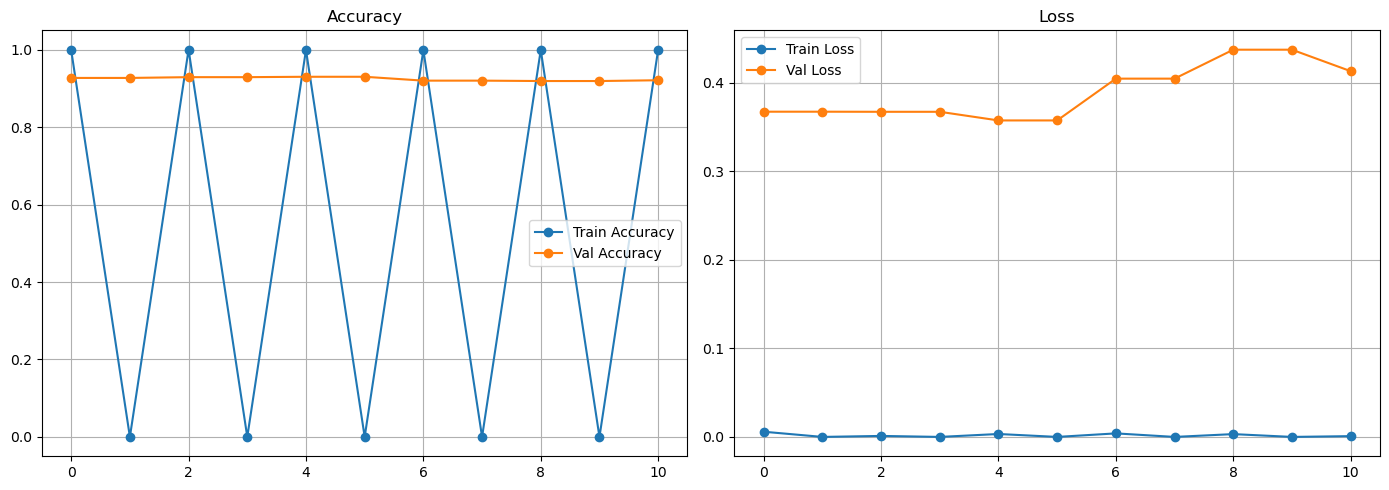

In [45]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel de la fonction après le fit
plot_training_history(history)

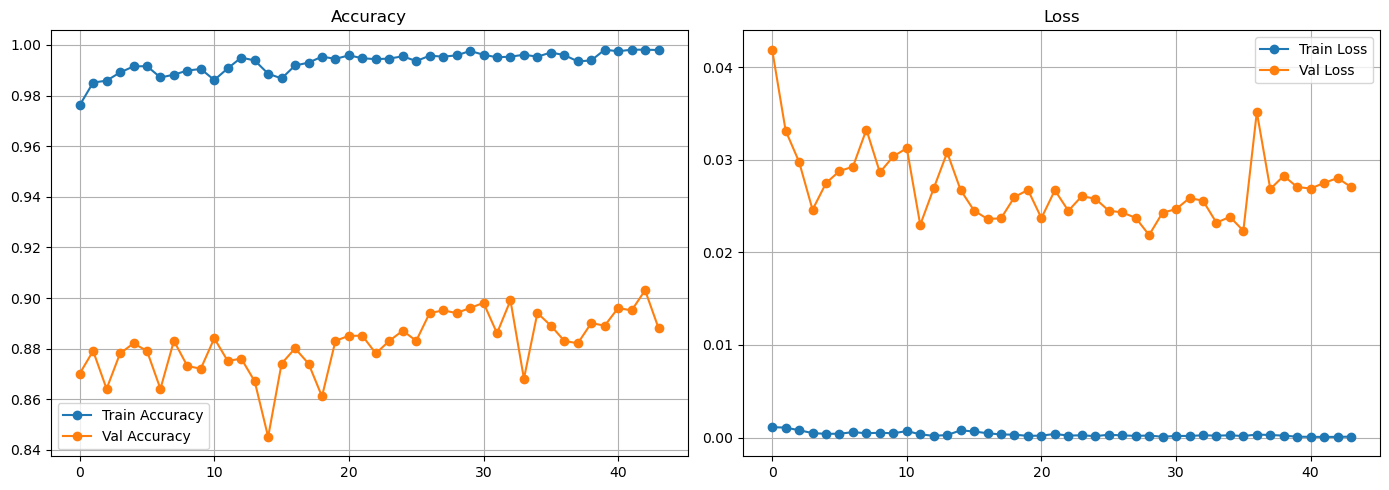

In [117]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel de la fonction après le fit
plot_training_history(history)

Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_4793/1519814059.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


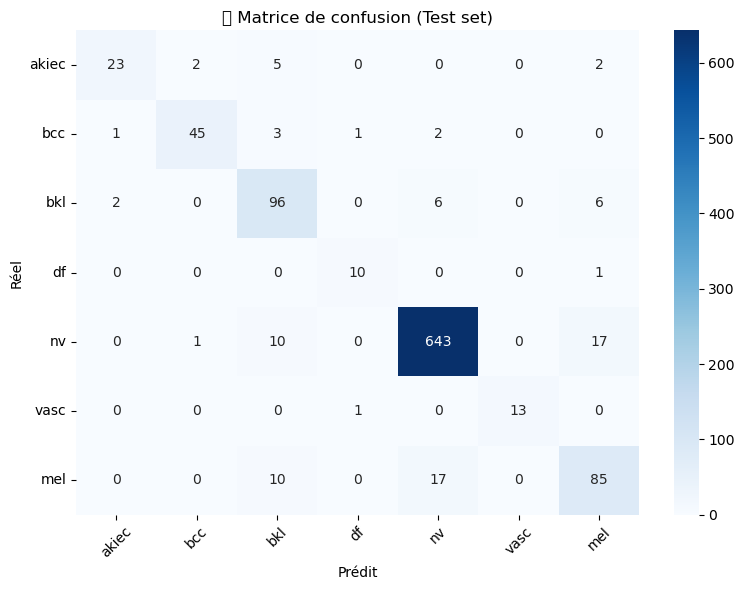


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.88      0.72      0.79        32
         bcc       0.94      0.87      0.90        52
         bkl       0.77      0.87      0.82       110
          df       0.83      0.91      0.87        11
          nv       0.96      0.96      0.96       671
        vasc       1.00      0.93      0.96        14
         mel       0.77      0.76      0.76       112

    accuracy                           0.91      1002
   macro avg       0.88      0.86      0.87      1002
weighted avg       0.92      0.91      0.91      1002



In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (299, 299)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))


Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1918/1519814059.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


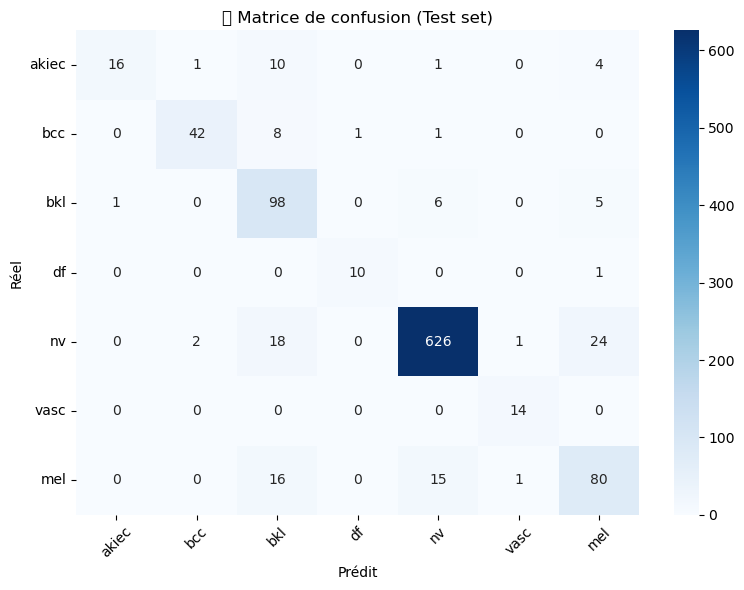


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.94      0.50      0.65        32
         bcc       0.93      0.81      0.87        52
         bkl       0.65      0.89      0.75       110
          df       0.91      0.91      0.91        11
          nv       0.96      0.93      0.95       671
        vasc       0.88      1.00      0.93        14
         mel       0.70      0.71      0.71       112

    accuracy                           0.88      1002
   macro avg       0.85      0.82      0.82      1002
weighted avg       0.90      0.88      0.89      1002



In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (299, 299)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))


Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1127/1549519804.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


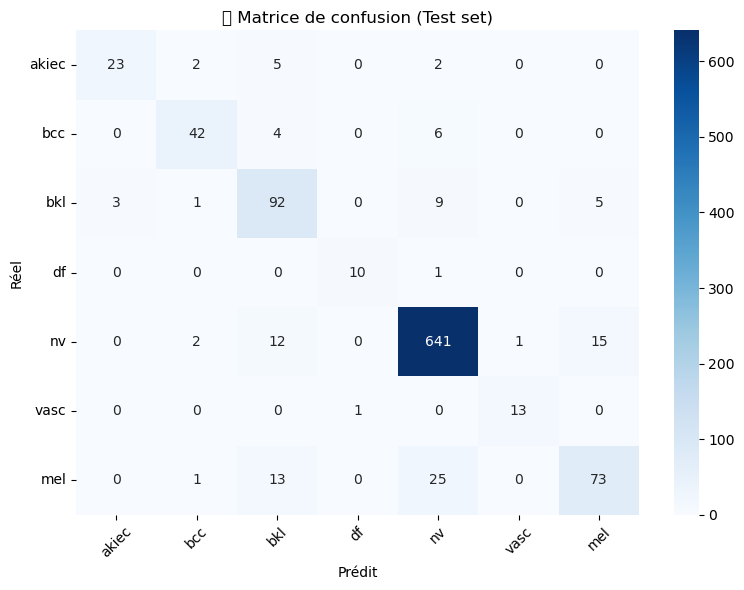


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.88      0.72      0.79        32
         bcc       0.88      0.81      0.84        52
         bkl       0.73      0.84      0.78       110
          df       0.91      0.91      0.91        11
          nv       0.94      0.96      0.95       671
        vasc       0.93      0.93      0.93        14
         mel       0.78      0.65      0.71       112

    accuracy                           0.89      1002
   macro avg       0.86      0.83      0.84      1002
weighted avg       0.89      0.89      0.89      1002



In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (299, 299)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_gen.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 515ms/step


AttributeError: 'TargetedAugmentGenerator' object has no attribute 'classes'

/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 312ms/step


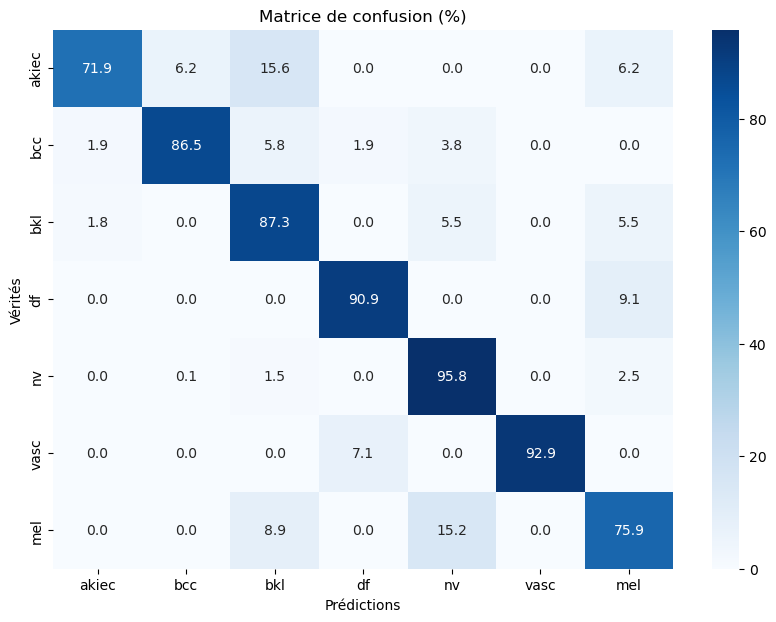

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step


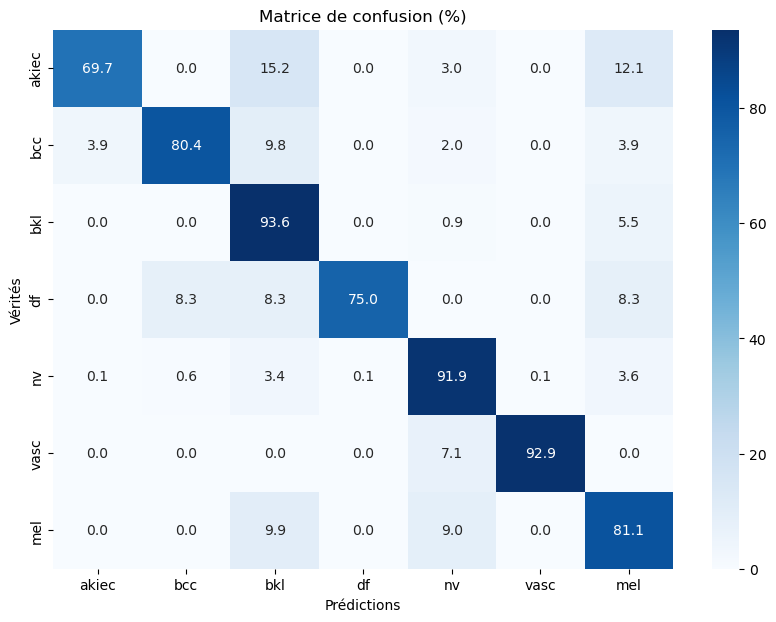

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 279ms/step


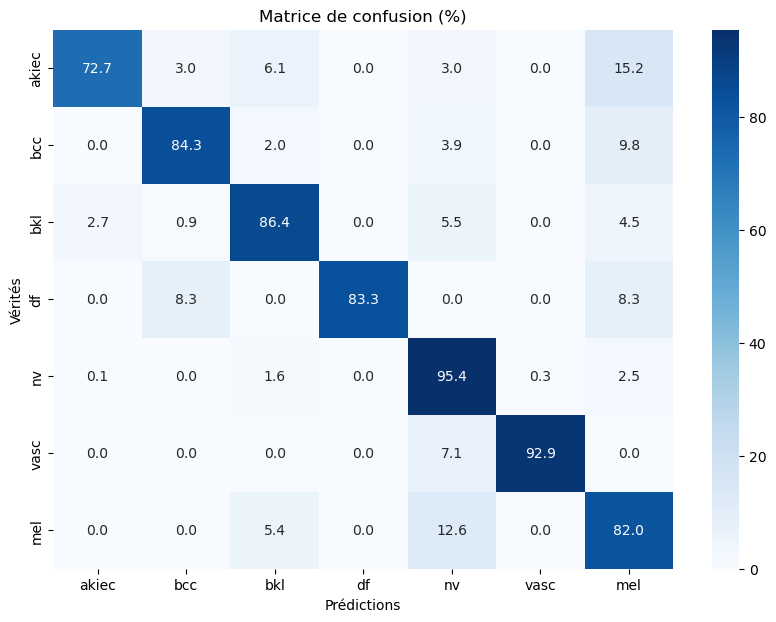

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()




In [21]:
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

@register_keras_serializable()
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            name='attention_weights',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True,
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = K.dot(inputs, self.attention_weights)
        weights = K.softmax(score, axis=1)
        context = weights * inputs
        return K.sum(context, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


In [25]:
model_loaded = load_model("Xception-Attention.keras", compile=False, custom_objects={"SimpleAttention": SimpleAttention})
# Trouvez le nom de votre couche base_model (Xception) dans model_loaded.summary()
# Supposons que son nom soit 'xception'
xception_layer_loaded = model_loaded.get_layer('xception') # Remplacez 'xception' par le vrai nom
print("Output shape of loaded Xception:", xception_layer_loaded.output_shape)

ValueError: Input 0 of layer "global_average_pooling2d" is incompatible with the layer: expected ndim=4, found ndim=3. Full shape received: (None, 10, 2048)

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.layers import Layer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# Exemple d'une classe d'attention correctement sérialisable
@tf.keras.utils.register_keras_serializable()
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            name='att_weights',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        # Simple attention via softmax over dense projection
        scores = tf.matmul(inputs, self.attention_weights)
        weights = tf.nn.softmax(scores, axis=1)
        output = tf.reduce_sum(inputs * weights, axis=1)
        return output

# ⬇️ Charger tes données
# ⚠️ Assure-toi que test_df est défini (ex: par lecture d’un CSV avant ce point)
# test_df = pd.read_csv('ton_fichier.csv')
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle avec la custom layer
model = load_model("Xception-Attention.keras", compile=False, custom_objects={"SimpleAttention": SimpleAttention})


# 5. Prétraitement d'image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 8. Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 9. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 10. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


ValueError: Input 0 of layer "global_average_pooling2d" is incompatible with the layer: expected ndim=4, found ndim=3. Full shape received: (None, 10, 2048)

2025-06-21 15:30:16.688036: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step


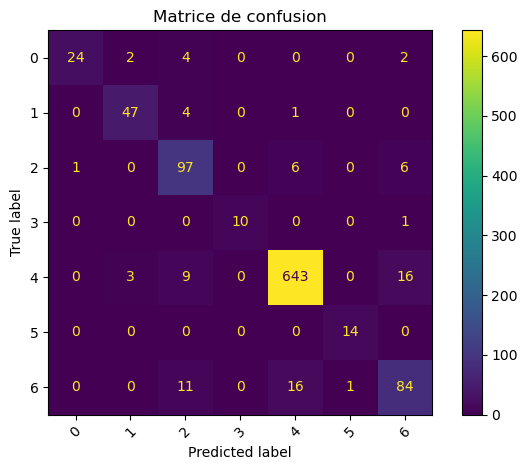

Rapport de classification :
              precision    recall  f1-score   support

           0       0.96      0.75      0.84        32
           1       0.90      0.90      0.90        52
           2       0.78      0.88      0.83       110
           3       1.00      0.91      0.95        11
           4       0.97      0.96      0.96       671
           5       0.93      1.00      0.97        14
           6       0.77      0.75      0.76       112

    accuracy                           0.92      1002
   macro avg       0.90      0.88      0.89      1002
weighted avg       0.92      0.92      0.92      1002



In [14]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-Xception-phaseSansTAG-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step


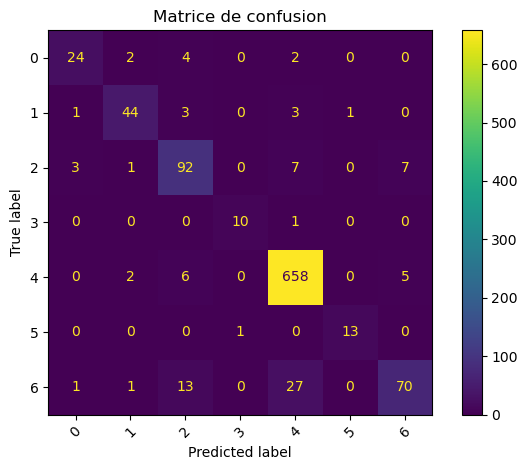

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.88      0.85      0.86        52
           2       0.78      0.84      0.81       110
           3       0.91      0.91      0.91        11
           4       0.94      0.98      0.96       671
           5       0.93      0.93      0.93        14
           6       0.85      0.62      0.72       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [7]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-InceptionV3-phase13-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step


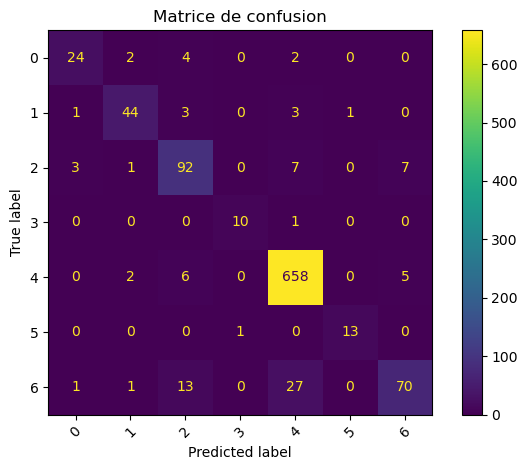

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.88      0.85      0.86        52
           2       0.78      0.84      0.81       110
           3       0.91      0.91      0.91        11
           4       0.94      0.98      0.96       671
           5       0.93      0.93      0.93        14
           6       0.85      0.62      0.72       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [6]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-InceptionV3-phase13-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


2025-06-21 10:26:56.930182: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-06-21 10:26:56.930220: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-06-21 10:26:56.930224: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1750494416.930245  146077 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1750494416.930275  146077 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-06-21 10:27:03.085812: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step


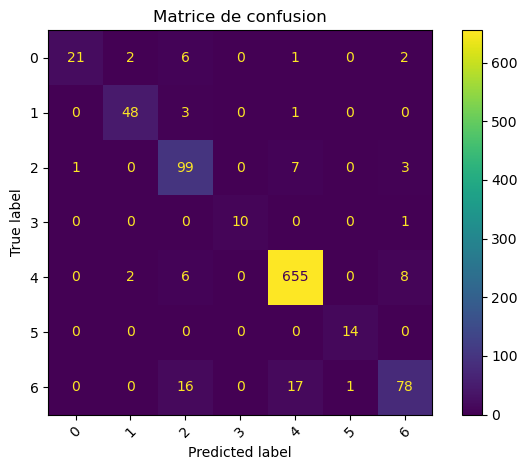

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      0.66      0.78        32
           1       0.92      0.92      0.92        52
           2       0.76      0.90      0.82       110
           3       1.00      0.91      0.95        11
           4       0.96      0.98      0.97       671
           5       0.93      1.00      0.97        14
           6       0.85      0.70      0.76       112

    accuracy                           0.92      1002
   macro avg       0.91      0.87      0.88      1002
weighted avg       0.92      0.92      0.92      1002



In [10]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-Xception-phase9-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 304ms/step


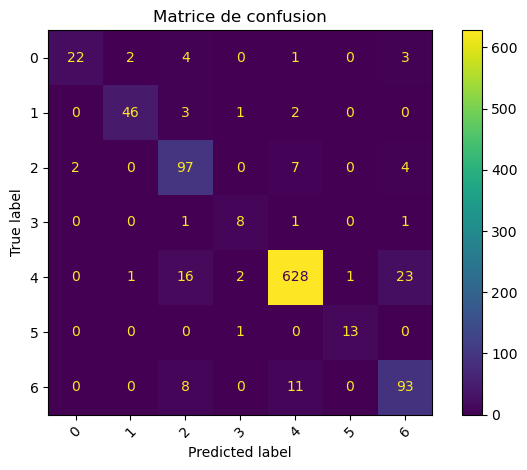

Rapport de classification :
              precision    recall  f1-score   support

           0       0.92      0.69      0.79        32
           1       0.94      0.88      0.91        52
           2       0.75      0.88      0.81       110
           3       0.67      0.73      0.70        11
           4       0.97      0.94      0.95       671
           5       0.93      0.93      0.93        14
           6       0.75      0.83      0.79       112

    accuracy                           0.91      1002
   macro avg       0.85      0.84      0.84      1002
weighted avg       0.91      0.91      0.91      1002



In [75]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('SBXception-Basic-LowReg_best_accuracy.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step


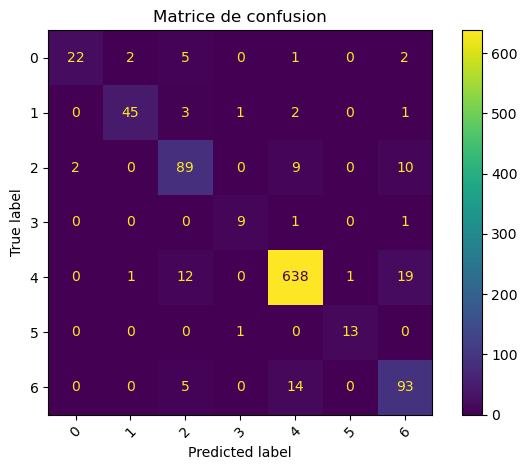

Rapport de classification :
              precision    recall  f1-score   support

           0       0.92      0.69      0.79        32
           1       0.94      0.87      0.90        52
           2       0.78      0.81      0.79       110
           3       0.82      0.82      0.82        11
           4       0.96      0.95      0.96       671
           5       0.93      0.93      0.93        14
           6       0.74      0.83      0.78       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [16]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('SBXception-Basic-LowReg_best_accuracy.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))
